# STAT 207 Project 02 - Analyzing US Video Game Sales Using Simulation-Based Inferences

Aditya LN, Ben Leardi, Carlos Bustamante

<hr>

## Contribution Report

Should we grade your submission?  If not, write the netID of the submission to be graded.  (Note: We will only grade one assignment per group, and we'll pick the first one that says we should grade that submission.  We will assign the same grade to all team members.)

*For example*, you might respond: **grade this submission** or **my submission is under netID jdeeke**

Grade this submission

If you said **my submission is under netID** above, we will not grade any of your project submission.

If you said **grade this submission** above, who worked with you on this project?  Write both their **names** and **netIDs**.  

Aditya LN - adityal2, Benjamin Leardi - blear (myself), Carlos Bustamente - carlosb7

You should list the contribution of each team member to the report.

*For example:*

*John Smith (smith92) & Jane Doe (doe105) worked together on all parts of this project*

OR

<i>1. John Smith (smith92) completed parts 1 - 3</i>

<i>2. Jane Doe (doe105) completed parts 4 - 5</i>

<i>We both reviewed the full document before submission.</i>

Worked on all parts of report together: Benjamin Leardi (blear), Aditya LN (adityal2), Carlos Bustamente (carlosb7)

Group Work Reflection

Reflecting on your experience working as a group, how do you think the project went?  What were the most effective things your group did to work together?  What were the least effective things your group did to work together?  What have you learned about group work since the last project?  What might you change about your group's process or dynamics for the next project?  Did you face any substantial challenges in working together?  If so, please explain any challenges that you had.

*Note*: this can be completed individually or as a group, and each person can submit their own reflection to their own repository/submission or completely within the group submission.  If you would like your TA to read your individual reflection and yours is not the submission to be graded, be sure to email your TA.

The project went well. We colaborated over google meet to work on our project together. We had no issues with our project. 

## 1. Introduction

In this notebook we analyse data originally collected and curated by Dr. Joe Cox. 
This data is a sample of late 2000s video game metrics. It includes variables such as US Sales, console the video game was released on, and cost of the game. The dataset also includes many different categories to divide the games, including sports and publisher.

(Link/reference: Video Games Dataset, University of Portsmouth Research Portal: https://researchportal.port.ac.uk/en/datasets/video-games-dataset)

We chose this dataset because game developers often look to succesful games from the past to draw inspiration for their work creating the games of the future. We choose to perform analysis to figure out the relation between sales and video game metrics to help guide game developers as they look to older games, helping them develop games that are both enjoyable and profitable. 

The Research Questions we looked at are:

**Research Question 1:** What is the proportion of games inside of our data set that are first person? What is a range of reasonable values for the proportion of this variable in our population, is this consistent yer over year?

By answering this question we get a sense for trends in First Person game development. A developer may combine this with their knowledge of the games of the Era to understand the role First Person Gaming may have played in shaping the industry as a whole.

**Research Question 2:** What is the average US video games sales from 2004 to 2010? Is it greater than 1 million copies of a game sold?

By answering this question, someone could see how popular and how much money video games could produce. This could help determine the success of video games throughout the years. 



In [1]:
#Imports here
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns

In [2]:
df = pd.read_csv("video_games.csv", encoding = "unicode-escape")
df

,Console,Title,US Sales (millions),Block4,Block2,Block1,Block0.5,YearReleased,2004,2005,...,Tricks,Volleyball,Wakeboarding,Wrestling,FirstPerson,Platform,Isometric,SideScrolling,TopDown,ThirdPerson
0,Nintendo DS,Super Mario 64 DS,4.69,1,1,1,1,2004,1,0,...,0,0,0,0,0,1,0,0,0,1
1,Sony PSP,Lumines: Puzzle Fusion,0.56,0,0,0,1,2004,1,0,...,0,0,0,0,0,0,0,0,0,0
2,Nintendo DS,WarioWare Touched!,0.54,0,0,0,1,2004,1,0,...,0,0,0,0,0,1,1,1,1,1
3,Sony PSP,Hot Shots Golf: Open Tee,0.49,0,0,0,0,2004,1,0,...,0,0,0,0,0,0,0,0,0,1
4,Nintendo DS,Spider-Man 2,0.45,0,0,0,0,2004,1,0,...,0,0,0,0,0,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1765,PlayStation 3,MotoGP 09/10,0.04,0,0,0,0,2010,0,0,...,0,0,0,0,1,0,0,0,0,1
1766,PlayStation 3,Prison Break: The Conspiracy,0.04,0,0,0,0,2010,0,0,...,0,0,0,0,0,0,0,0,0,1
1767,Nintendo Wii,"Sakura Wars: So Long, My Love",0.04,0,0,0,0,2010,0,0,...,0,0,0,0,0,0,0,0,0,1
1768,X360,Record of Agarest War (The Really Naughty Limi...,0.04,0,0,0,0,2010,0,0,...,0,0,0,0,0,0,1,0,0,0


In [3]:
# columns 
list(df.columns)

['Console',
 'Title',
 'US Sales (millions)',
 'Block4',
 'Block2',
 'Block1',
 'Block0.5',
 'YearReleased',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 'YearReleasedSq',
 'Publisher',
 'Genre',
 'Sequel',
 'Re-release',
 'Usedprice',
 'lnUsedPrice',
 'Review Score',
 'ReviewSq',
 'RatingE',
 'RatingT',
 'RatingM',
 'Lifecycle',
 'LifecycleSq',
 'MaxPlayers',
 'MaxPlayersSq',
 'Online',
 'Licensed',
 'Handheld',
 'Accessory',
 'LtdEdition',
 'Multiplatform',
 'GBA',
 'GCN',
 'NDS',
 'Wii',
 'PS2',
 'PS3',
 'PSP',
 'Xbox',
 'X360',
 'Action',
 'Adventure',
 'Educational',
 'Racing',
 'RPG',
 'Simulation',
 'Sports',
 'Strategy',
 '2K',
 'Acclaim',
 'Activision',
 'Atari',
 'Capcom',
 'Disney',
 'Eidos',
 'EA',
 'Infograme',
 'Konami',
 'Microsoft',
 'Midway',
 'Namco',
 'Nintendo',
 'Rockstar',
 'Sony',
 'Sega',
 'THQ',
 'SquareEnix',
 'Ubisoft',
 'Adult',
 'Anime',
 'Arcade',
 'Battlemech',
 'Boardgame',
 'Cards',
 'Casino',
 'Chess',
 'Comics',
 'Cyberpunk',
 'Dete

In [4]:
#initial grouping of interesting data
data = df[["US Sales (millions)", "Console", "Title", "YearReleased", "MaxPlayers", "Review Score",'Usedprice','TurnBased','FirstPerson','ThirdPerson','Strategy','Online']]
data

,US Sales (millions),Console,Title,YearReleased,MaxPlayers,Review Score,Usedprice,TurnBased,FirstPerson,ThirdPerson,Strategy,Online
0,4.69,Nintendo DS,Super Mario 64 DS,2004,1,85,24.95,0,0,1,0,0
1,0.56,Sony PSP,Lumines: Puzzle Fusion,2004,1,89,14.95,0,0,0,1,1
2,0.54,Nintendo DS,WarioWare Touched!,2004,2,81,22.95,0,0,1,0,0
3,0.49,Sony PSP,Hot Shots Golf: Open Tee,2004,1,81,12.95,0,0,1,0,1
4,0.45,Nintendo DS,Spider-Man 2,2004,1,61,14.95,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1765,0.04,PlayStation 3,MotoGP 09/10,2010,1,70,39.95,0,1,1,0,0
1766,0.04,PlayStation 3,Prison Break: The Conspiracy,2010,1,41,32.95,0,0,1,0,0
1767,0.04,Nintendo Wii,"Sakura Wars: So Long, My Love",2010,1,74,24.95,1,0,1,1,0
1768,0.04,X360,Record of Agarest War (The Really Naughty Limi...,2010,1,71,49.95,0,0,0,1,0


In [5]:
df['Lifecycle']

0       0
1       0
2       0
3       0
4       0
       ..
1765    4
1766    4
1767    4
1768    5
1769    6
Name: Lifecycle, Length: 1770, dtype: int64

## 2. Confidence Intervals on FirstPerson 

What is the proportion of games inside of our data set that are first person? What is a range of reasonable values for the proportion of this variable in our population, is this consistent yer over year?

The following Cells use simulation based inferance to Calculate a Confidence intervals for each year in our data, we use this information to visualize trends in the popularity of First Person Game development. we will utilize 95% intervals everywhere.

In [6]:
#the data
data["FirstPerson"]

0       0
1       0
2       0
3       0
4       0
       ..
1765    1
1766    0
1767    0
1768    0
1769    0
Name: FirstPerson, Length: 1770, dtype: int64

In [7]:
# We do not Obsereve any missing data
data[["FirstPerson"]].isna().sum()

FirstPerson    0
dtype: int64

In [8]:
#Our data is recorded as integers. 1 represents True (is a First Person Game), 0 represents False (is not a First Person Game)
data[["FirstPerson"]].dtypes 

FirstPerson    int64
dtype: object

In [9]:
#what values are in our data?
data["FirstPerson"].value_counts()

FirstPerson
0    1347
1     423
Name: count, dtype: int64

In [10]:
# some descriptive analystics
print(f"the size of our sample is {len(data["FirstPerson"])} records")
print(f"the proportion of games the are First Person in our sample is {data["FirstPerson"].mean()}")
print(f"A large majority of games were not First Person in our sample from 2004 to 2010")

the size of our sample is 1770 records
the proportion of games the are First Person in our sample is 0.23898305084745763
A large majority of games were not First Person in our sample from 2004 to 2010


In [11]:
#generating a sampling distribution from the entire sample
full_sampling = pd.DataFrame({"sample_means" : [data.sample(n=len(data), replace = True)["FirstPerson"].mean() for _ in range(100000)]})
full_sampling

,sample_means
0,0.243503
1,0.242373
2,0.253672
3,0.241243
4,0.219209
...,...
99995,0.235593
99996,0.206215
99997,0.229944
99998,0.235593


Text(0, 0.5, 'Frequency')

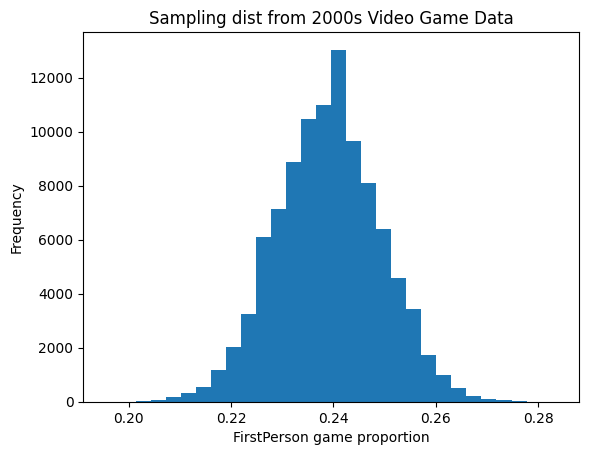

In [12]:
#visualising full_sampling, The resultant histogram looks roughly normal
plt.hist(full_sampling["sample_means"], bins = 30)
plt.title("Sampling dist from 2000s Video Game Data")
plt.xlabel("FirstPerson game proportion")
plt.ylabel("Frequency")

In [13]:
#the 95% confidence interval of FirstPerson% from 2004-10
overall_ci = [full_sampling["sample_means"].quantile(0.025), full_sampling["sample_means"].quantile(0.975)]
overall_ci

[np.float64(0.2192090395480226), np.float64(0.25875706214689265)]

In [14]:
#repeat the process for each year sepreately
samplings_by_year = [
    pd.DataFrame({"sample_means" : [data[data.YearReleased == 2004 + i].sample(n=len(data[data.YearReleased == 2004 + i]), replace = True)["FirstPerson"].mean() 
                                    for _ in range(10000)]}) for i in range(7)
    ]
samplings_by_year

[      sample_means
 0         0.217391
 1         0.304348
 2         0.130435
 3         0.260870
 4         0.217391
 ...            ...
 9995      0.086957
 9996      0.260870
 9997      0.130435
 9998      0.217391
 9999      0.173913
 
 [10000 rows x 1 columns],
       sample_means
 0         0.273333
 1         0.193333
 2         0.253333
 3         0.280000
 4         0.226667
 ...            ...
 9995      0.273333
 9996      0.206667
 9997      0.240000
 9998      0.206667
 9999      0.200000
 
 [10000 rows x 1 columns],
       sample_means
 0         0.221088
 1         0.231293
 2         0.241497
 3         0.231293
 4         0.255102
 ...            ...
 9995      0.200680
 9996      0.282313
 9997      0.193878
 9998      0.227891
 9999      0.207483
 
 [10000 rows x 1 columns],
       sample_means
 0         0.277419
 1         0.262366
 2         0.290323
 3         0.273118
 4         0.335484
 ...            ...
 9995      0.322581
 9996      0.247312
 9997      0.

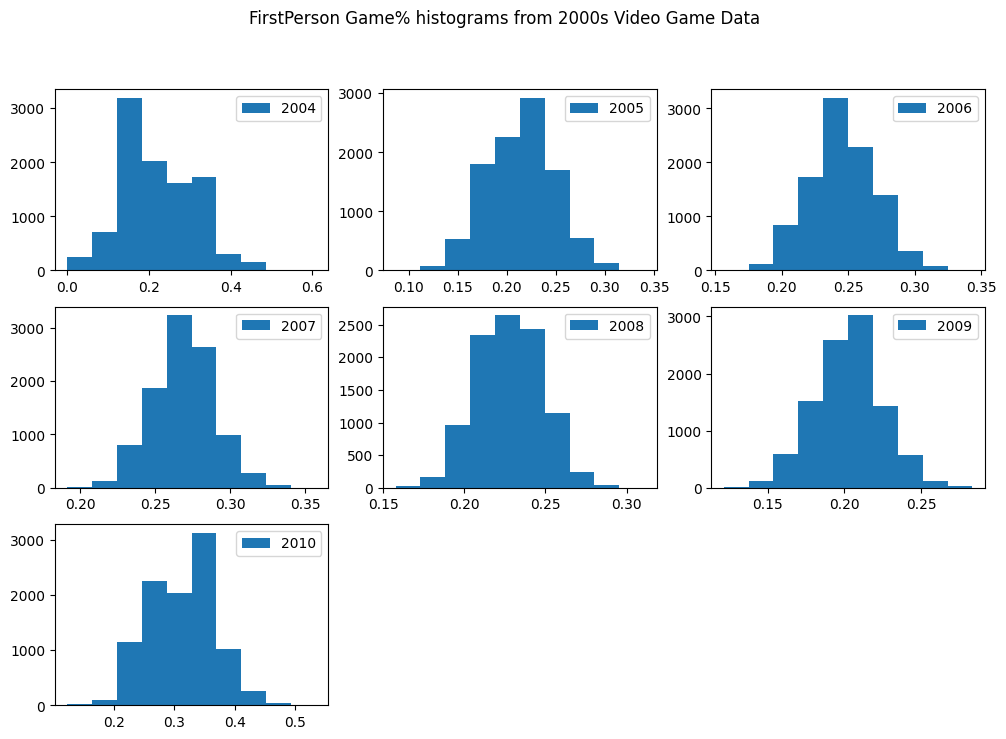

In [15]:
#visualizing samplings_by_year, all appear to be roughly normal
plt.figure(figsize=(12,8))
plt.suptitle("FirstPerson Game% histograms from 2000s Video Game Data")
for i in range(7):
    plt.subplot(3, 3, i+1)
    plt.hist(samplings_by_year[i]["sample_means"], label = f"{2004+i}")
    plt.legend()

In [16]:
#calculating confidence intervals by year
confidence_intervals_by_year = [[samplings_by_year[i]["sample_means"].quantile(0.025), samplings_by_year[i]["sample_means"].quantile(0.975)] for i in range(7)]
confidence_intervals_by_year

[[np.float64(0.043478260869565216), np.float64(0.391304347826087)],
 [np.float64(0.15333333333333332), np.float64(0.28)],
 [np.float64(0.19727891156462585), np.float64(0.29591836734693877)],
 [np.float64(0.22795698924731184), np.float64(0.3096774193548387)],
 [np.float64(0.1891891891891892), np.float64(0.26576576576576577)],
 [np.float64(0.1588785046728972), np.float64(0.24610591900311526)],
 [np.float64(0.2191780821917808), np.float64(0.4246575342465753)]]

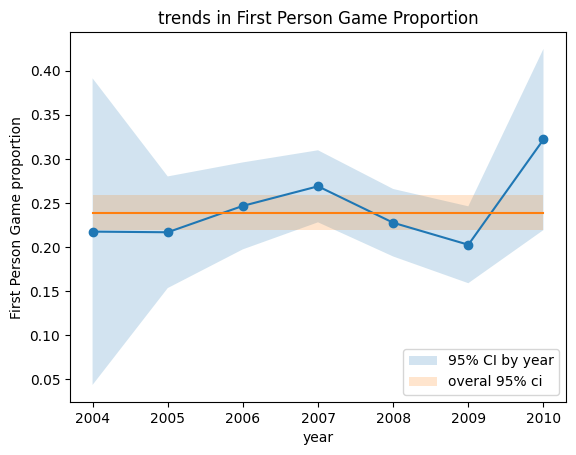

In [17]:
ci_array = np.array(confidence_intervals_by_year)

low, high = ci_array[:, 0], ci_array[:, 1]
mid = (low + high) / 2

plt.fill_between(range(2004,2011), low, high, alpha=0.2, label='95% CI by year')
plt.fill_between(range(2004,2011), overall_ci[0], overall_ci[1], alpha = 0.2, label = "overal 95% ci")
plt.plot(range(2004,2011), mid, marker='o')
plt.plot(range(2004,2011), [sum(overall_ci)/2]*7)
plt.ylabel("First Person Game proportion")
plt.xlabel("year")
plt.title("trends in First Person Game Proportion")
plt.legend()

## 3. Hypothesis Testing Analytical Tasks

What is the average US video games sales from 2004 to 2010? Is it greater than 1 million copies of a game sold?

The following cells will use a simulation-based approach to conduct a hypothesis test on US video game sales. We will evalutate our null hypothesis, use a significance level of 0.05, and compute a p value to determine whether there is evidence to support our alternative hypothesis.

Our variable of interest is "US Sales (millions)"

In [ ]:
# cleaning our data
sales = df["US Sales (millions)"]


In [ ]:
# checking if there are na values inside of the dataset
sales.isna().sum()

np.int64(0)

In [21]:
# sample size
print(len(sales))

1770


In [ ]:
# numerical summaries of our variable US Sales (millions) inccluding the mean, median, std, min, and max.
sales.describe()

count    1770.000000
mean        0.479785
std         1.064915
min         0.010000
25%         0.090000
50%         0.190000
75%         0.450000
max        14.660000
Name: US Sales (millions), dtype: float64

Text(0.5, 1.0, 'Distribution of US video game sales in millions')

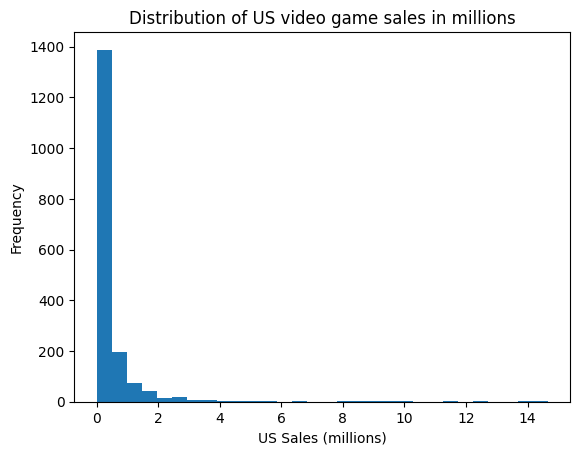

In [28]:
# histogram of our variable of interest
plt.hist(sales, bins=30)
plt.xlabel("US Sales (millions)")
plt.ylabel("Frequency")
plt.title("Distribution of US video game sales in millions")


The best meadsure of center to describe my variable of interest would be the median. The graph is right skewed and influenced by extreme values. The distribution indicates that most games sell smaller numbers of copies, while there are still some games that are very popular and sell many copies.

## Hypothesis Test:## 

Let '$\mu$' represent the mean US Sales (millions) of video games in our dataset. This is our variable of interest that we will be testing.

H_0: '$\mu$' = 1
H_1: '$\mu$' > 1

In [ ]:
# observed mean and null value
observed_mean = sales.mean()
print(observed_mean)
null_value = 1

0.47978531073446323


In [31]:
# sampling distribution
simulated_means = []
for i in range(1000):
    sample = sales.sample(n=1770, replace=True)
    simulated_means.append(sample.mean())
pd.Series(simulated_means)

0      0.480186
1      0.484480
2      0.472774
3      0.471836
4      0.516480
         ...   
995    0.505503
996    0.539469
997    0.507249
998    0.480893
999    0.480339
Length: 1000, dtype: float64

Text(0.5, 1.0, 'Sampling Distribution')

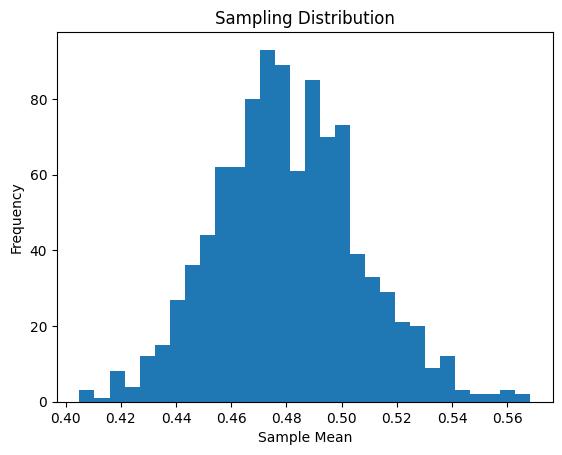

In [33]:
plt.hist(simulated_means, bins=30)
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.title("Sampling Distribution")


In [35]:
# p value
p_value = (simulated_means >= observed_mean).mean()
print(p_value)

0.495


In [36]:
# Decision
alpha = 0.05

if (p_value < alpha):
    print("Reject null hypothesis")
else:
    print("Fail to reject the null hypothsis")

Fail to reject the null hypothsis


Since the p-value is greater than 0.05, there is not enough evidence to say the average US video game sales from 2004 to 2010 is above 1 million. The p-value represents the probability of observing a sample mean as large as the one obtained. 

## Any other type of analysis/question you want to explore with this dataset.

<u>Why?</u>: Sometimes undergraduate students will put the research projects that they did for their classes on their resumes when applying for graduate schools, internships, and jobs. If you're interested in showcasing cool analyses to write on your resume, this section could help with that. **(This section is not worth any points though).**

## 4. Conclusion

Throughout our confidence interval test, we answered the questions, "What is the proportion of games inside of our data set that are first person? What is a range of reasonable values for the proportion of this variable in our population, is this consistent year over year?" First, we cleaned the data to make sure there were no NA values and separated it to include our variable of interest. Then, we created a sampling distribution to show the sample means of our data set. Then we created more distributions for each year the dataset covered (2004 - 2010). For our hypothesis test, we answered the questions, "What is the average US video games sales from 2004 to 2010? Is it greater than 1 million copies of a game sold?" We continued our data cleaning process by separating our variable of interest from the dataset and making sure there were no NA values. We created numerical summaries and a histogram of our variable of interest. We then created a sampling distribution to explore sample means compared to the observed mean. From there, we found our p-value and proved our null hypothesis to be false.

Some limitations from our dataset include it being observational and not experimental. We can only make associations, not causations. Along with this, the distribution of US video game sales is very right skewed, with a small number of outliers. This could reduce the creditability of the mean statistic. A game developer or marketer should proceed cautiously when exploring our report. We find general trends rather than definite conclusions. 

## AI Acknowledgement

Our course policy is that you should write all of your own interpretations and other narrative answers (phrases or sentences) yourself without the assistance of AI.  

You may use AI to help guide your code, although you should write all of your own code yourself (not copy-paste from another source) and you should cite your use of AI.  I would encourage you to try to generate any necessary code yourself first using course resources and using AI as a debugging tool if/when you reach an error that you can't figure out or to help you perform any coding tasks that are more advanced than we've demonstrated during class.  

Did you use AI on this assignment?  Did you use other resources outside of our course-provided resources on this assignment?

We did not use AI

If you used AI or other resources, answer the following questions to cite your usage.

- Which AI and/or resources did you use?
- What prompts did you ask it?
- How did you integrate the responses into your assignment?  Specifically, which questions or parts are associated with this usage?

Note: answering these three questions are enough for our course but may not be enough for a different course or context.

Did not use AI